# Feature Engineering 2.0
built upon 1.1.1 dataset 

In [1]:
import joblib
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from src.features import transformers
import pandas as pd
from sklearn import set_config
set_config(transform_output="pandas")


In [2]:
#loading files
dataset_path = "../data/interim/fe_1_1_1_data.pkl"
pipeline_path = "../data/interim/models/1_1_1_data_pipeline.pkl"

df = joblib.load(dataset_path)
pipeline = joblib.load(pipeline_path)


In [3]:
df.head()

,age,sex,height_inches,weight_pounds,bmi,num_people_in_house,sw_num_days_per_week,irreg_sched,sw_9am_start_diff,sw_5pm_end_diff,...,difficulty_operating_motor_vehicles_for_long_distances_fosq,difficulty_visiting_family_or_friends_in_their_home_fosq,relationships_with_family_or_friends_affected_fosq,difficulty_watching_a_movie_fosq,difficulty_being_active_in_evening_fosq,difficulty_being_active_in_morning_fosq,effect_on_desire_for_intimacy_or_sex_fosq,fosq_summary_score,type_of_pap_device,ahi
0,30,F,67,188.0,29.4,4,<NA>,False,-1.00,0.0,...,2,1,1,2,1.0,1.0,2,8,<NA>,0.4
1,30,F,67,165.0,25.8,3,3,True,-2.00,2.0,...,4,3,3,3,3.0,3.0,3,14,<NA>,1.0
2,42,M,64,156.0,26.8,0,7,True,-3.00,3.0,...,4,3,4,3,2.0,2.0,4,16,<NA>,3.9
3,36,M,63,255.0,45.2,3,5,True,-0.75,0.5,...,4,4,3,3,2.0,2.0,2,15,False,1.3
4,41,F,66,186.0,30.0,6,<NA>,None,NaN,NaN,...,<NA>,<NA>,<NA>,<NA>,NaN,NaN,<NA>,<NA>,<NA>,2.5


In [4]:
rfc_model = RandomForestClassifier(random_state=42)



X = df.drop("ahi", axis=1)

datetime_cols = X.select_dtypes(include=["datetime", "datetime64"]).columns

X = X.drop(columns=datetime_cols)


y = df["ahi"].where(df["ahi"] >= 5, 1).where(df["ahi"] < 5, 0)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train_transformed = pipeline.transform(X_train)
X_test_transformed = pipeline.transform(X_test)

rfc_model.fit(X_train_transformed, y_train)


/Users/jack/Repos/apnea-predictor/src/features/transformers.py:149: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[False False False ... True False False]' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  X_transformed.loc[:, self.columns] = self.imputer.transform(
/Users/jack/Repos/apnea-predictor/src/features/transformers.py:149: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[False False False ... False False False]' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  X_transformed.loc[:, self.columns] = self.imputer.transform(
/Users/jack/Repos/apnea-predictor/src/features/transformers.py:149: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[True True True ... False True True]' has dtype incompatibl

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [5]:
# TODO: this doesnt get full list of features gah

feature_names = X_train_transformed.columns.tolist()
importances = rfc_model.feature_importances_
feature_importance_df = pd.DataFrame({"feature": feature_names, "importance": importances}
 ).sort_values(by="importance", ascending=False)


In [6]:
import xgboost as xgb
import shap


model = xgb.XGBClassifier(random_state=42, n_estimators=1000, max_depth=6, learning_rate=0.01, subsample=0.8, colsample_bytree=0.8)
model.fit(X_train_transformed, y_train)

preds = model.predict(X_test_transformed)
print(classification_report(y_test, preds))


/Users/jack/Repos/apnea-predictor/conda_env/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


              precision    recall  f1-score   support

         0.0       0.72      0.97      0.83       256
         1.0       0.46      0.06      0.11       101

    accuracy                           0.71       357
   macro avg       0.59      0.52      0.47       357
weighted avg       0.65      0.71      0.62       357



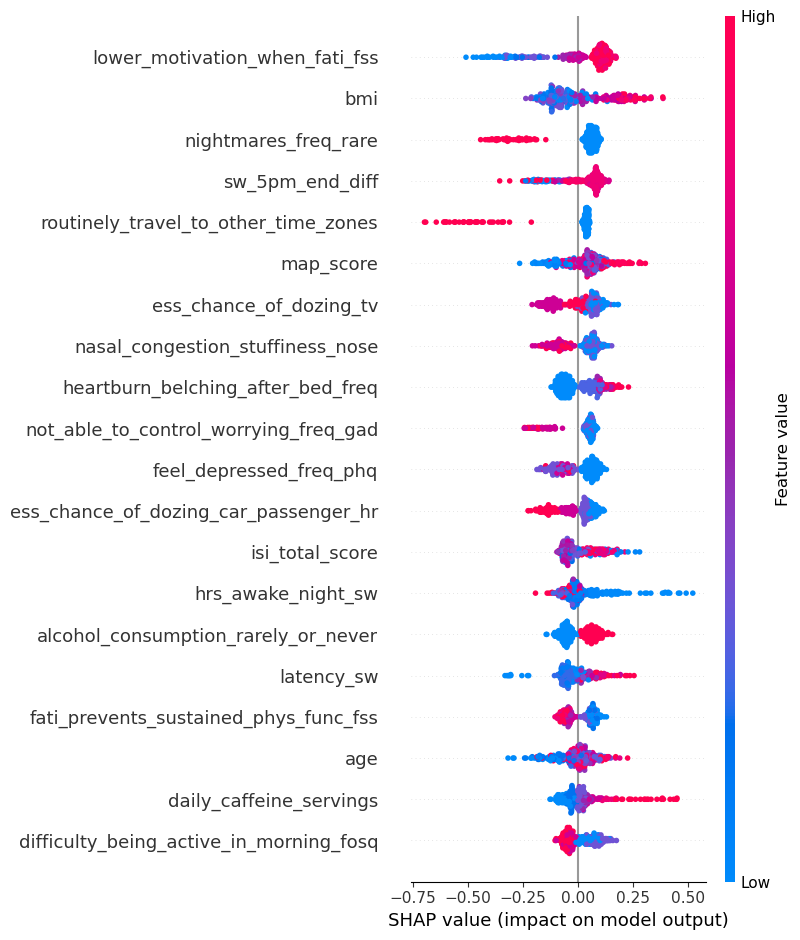

In [7]:
explainer = shap.TreeExplainer(model, X_train_transformed)
shap_values = explainer.shap_values(X_test_transformed)

explanations = explainer(X_test_transformed)

shap.summary_plot(shap_values, X_test_transformed)


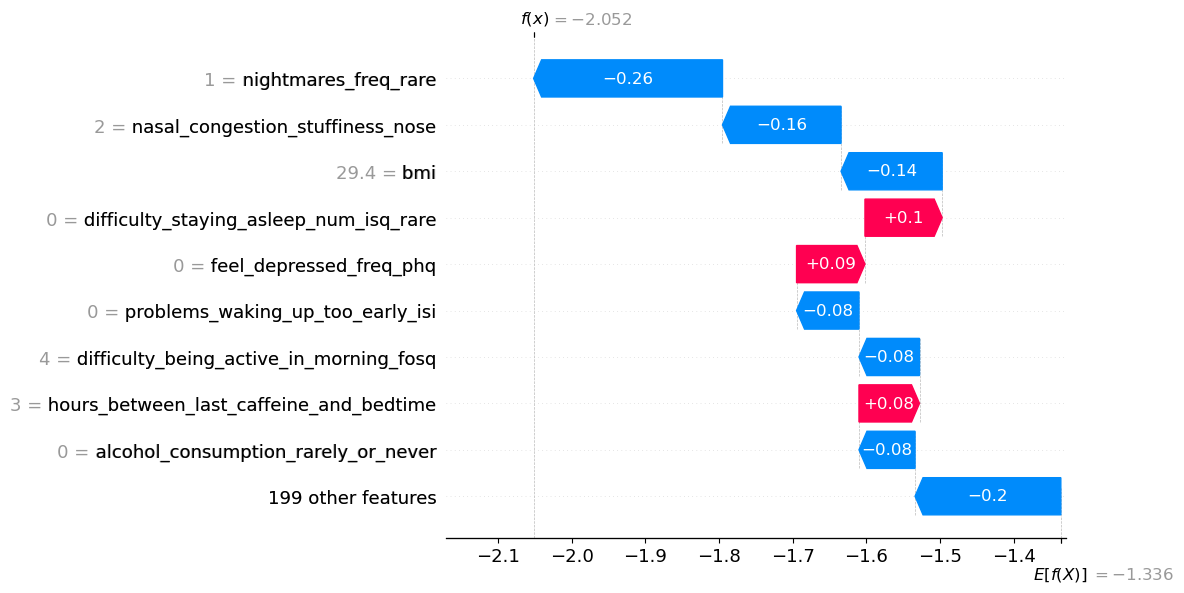

In [8]:
# random ass prediction

shap.plots.waterfall(explanations[1])

In [9]:
'''from sklearn.feature_selection import RFECV

selector = RFECV(estimator=model, step=1, cv=5, scoring='accuracy')

selector = selector.fit(X_train_transformed, y_train)
'''

"from sklearn.feature_selection import RFECV\n\nselector = RFECV(estimator=model, step=1, cv=5, scoring='accuracy')\n\nselector = selector.fit(X_train_transformed, y_train)\n"

In [10]:
'''import matplotlib.pyplot as plt
import pandas as pd

data = {
    key: value
    for key, value in selector.cv_results_.items()
    if key in ["n_features", "mean_test_score", "std_test_score"]
}
cv_results = pd.DataFrame(data)
plt.figure()
plt.xlabel("Number of features selected")
plt.ylabel("Mean test accuracy")
plt.errorbar(
    x=cv_results["n_features"],
    y=cv_results["mean_test_score"],
    yerr=cv_results["std_test_score"],
)
plt.title("Recursive Feature Elimination \nwith correlated features")
plt.show()'''

'import matplotlib.pyplot as plt\nimport pandas as pd\n\ndata = {\n    key: value\n    for key, value in selector.cv_results_.items()\n    if key in ["n_features", "mean_test_score", "std_test_score"]\n}\ncv_results = pd.DataFrame(data)\nplt.figure()\nplt.xlabel("Number of features selected")\nplt.ylabel("Mean test accuracy")\nplt.errorbar(\n    x=cv_results["n_features"],\n    y=cv_results["mean_test_score"],\n    yerr=cv_results["std_test_score"],\n)\nplt.title("Recursive Feature Elimination \nwith correlated features")\nplt.show()'

In [11]:
from sklearn.feature_selection import SelectFromModel
from sklearn.feature_selection import VarianceThreshold

vt_selector = VarianceThreshold(threshold=0.03)

vt_selector = vt_selector.fit(X_train_transformed)

X_train_vt = vt_selector.transform(X_train_transformed)
X_test_vt = vt_selector.transform(X_test_transformed)



In [12]:
model_selector = SelectFromModel(estimator=model, threshold="median")

model_selector = model_selector.fit(X_train_transformed, y_train)

model_selector.get_support()

X_train_selected = model_selector.transform(X_train_transformed)

X_test_selected = model_selector.transform(X_test_transformed)

X_train_selected.shape
X_train_selected

,age,height_inches,bmi,num_people_in_house,sw_num_days_per_week,sw_5pm_end_diff,nasal_congestion_stuffiness_nose,nasal_blockage_obstr_nose,not_enough_air_excercise_nose,alcohol_consumption_rarely_or_never,...,rls_unlikely_curr_probably_past_True,num_times_eat_drink_dur_sleep_never_unknown,num_times_eat_drink_dur_sleep_occasional,difficulty_falling_asleep_num_isq_occasional,difficulty_falling_asleep_num_isq_rare,difficulty_staying_asleep_num_isq_occasional,multiple_awakenings_num_isq_occasional,multiple_awakenings_num_isq_rare,remember_dreams_times_never_unknown,remember_dreams_times_rare
1296,41.0,69.0,19.9,2.0,5.0,0.0,3.0,3.0,0.0,1.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0
175,82.0,65.0,27.5,2.0,5.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0
886,32.0,69.0,22.9,1.0,6.0,3.5,2.0,2.0,3.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
1603,38.0,68.0,23.6,1.0,5.0,0.0,0.0,0.0,0.0,1.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0
481,76.0,64.0,33.8,2.0,5.0,0.0,1.0,0.0,0.0,1.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1130,41.0,66.0,32.9,4.0,5.0,0.0,2.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
1294,65.0,69.0,29.5,2.0,5.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0
860,51.0,74.0,32.1,3.0,3.0,-11.5,1.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
1459,35.0,74.0,29.5,2.0,5.0,-13.0,1.0,0.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0


In [13]:
# TODO: idk train model on both subsets of features and look at shapely stuff from thjere 

vt selected 213 features, select from model has 114

In [14]:
X_train_selected.shape

(1427, 104)

In [15]:
X_train_vt.shape

(1427, 197)

In [16]:
vt_model = xgb.XGBClassifier(random_state=42, n_estimators=1000, max_depth=6, learning_rate=0.01, subsample=0.8, colsample_bytree=0.8)
sfm_model = xgb.XGBClassifier(random_state=42, n_estimators=1000, max_depth=6, learning_rate=0.01, subsample=0.8, colsample_bytree=0.8)

vt_model.fit(X_train_vt, y_train)
sfm_model.fit(X_train_selected, y_train)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_metho

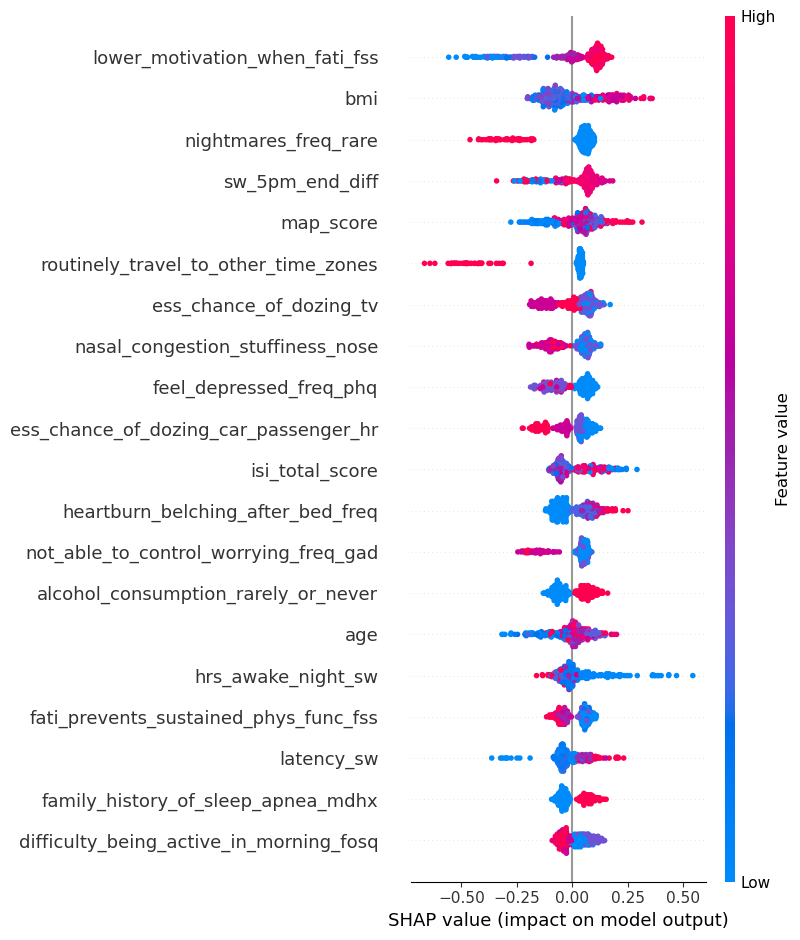

In [17]:
vt_explainer = shap.TreeExplainer(vt_model, X_train_vt)
shap_values = vt_explainer.shap_values(X_test_vt)

explanations = vt_explainer(X_test_vt)

shap.summary_plot(shap_values, X_test_vt)



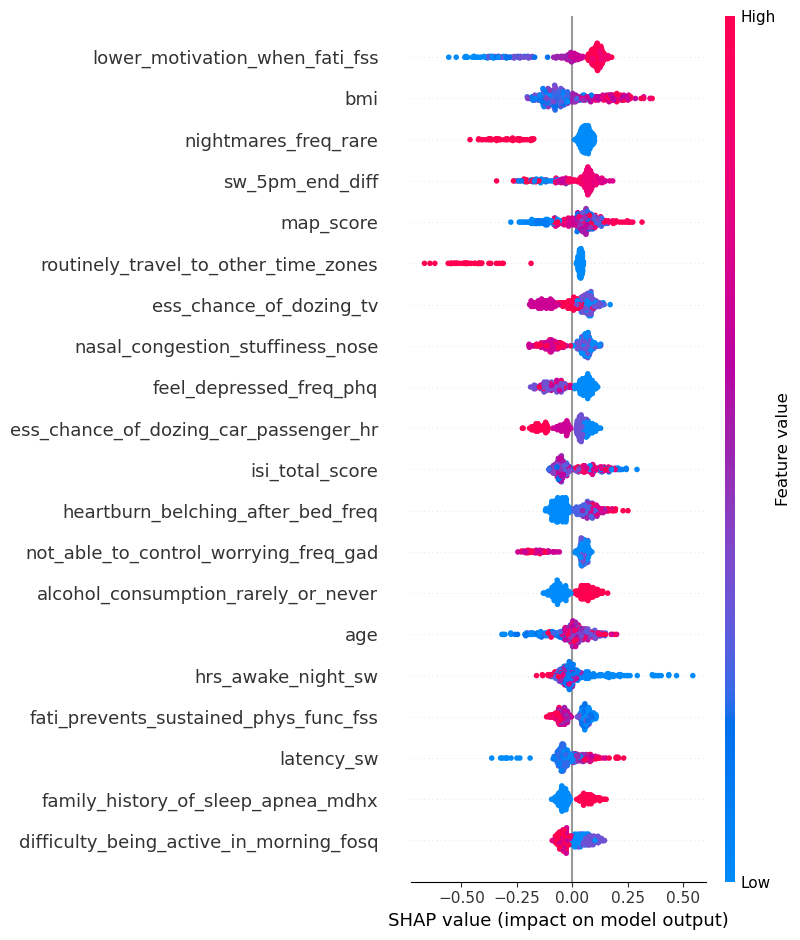

In [18]:
sfm_explainer = shap.TreeExplainer(sfm_model, X_train_selected)
sfm_shap_values = sfm_explainer.shap_values(X_test_selected)

explanations = sfm_explainer(X_test_selected)

shap.summary_plot(shap_values, X_test_vt)



they have determined the same set of features to be important it seems so one just has an extra 100

In [19]:
# find features not in one set

vt_features = X_train_vt.columns.tolist()

sfm_features = X_train_selected.columns.tolist()

diff_features = set(vt_features) - set(sfm_features)

diff_features = list(diff_features)

total_features = set(vt_features).union(set(sfm_features))

total_features = list(total_features)


In [20]:
display(len(vt_features))
display(len(sfm_features))
display(len(total_features))

""" 
2 features are different between the two sets
"""

197

104

198

' \n2 features are different between the two sets\n'

In [21]:
ft = set(total_features) - set(vt_features)

print(ft) #well...

{'family_history_of_narcolepsy_mdhx'}


In [22]:
orig_columns = X_train_transformed.columns.tolist()

missing = set(orig_columns) - set(total_features)
missing = list(missing)

missing # im pretty sure theese are just the features that have no variance or something 

['type_of_pap_device',
 'nap_num_rare',
 'wakeup_sw_varies',
 'family_history_of_death_during_sleep_mdhx',
 'map_likelihood_ration',
 'bedtime_sw_varies',
 'num_times_eat_drink_dur_sleep_rare',
 'current_treated_for_narcolepsy',
 'never_feel_rested',
 'congestive_heart_failure_mdhx']

In [23]:
preds = vt_model.predict(X_test_vt)
print(classification_report(y_test, preds))

              precision    recall  f1-score   support

         0.0       0.72      0.97      0.83       256
         1.0       0.46      0.06      0.11       101

    accuracy                           0.71       357
   macro avg       0.59      0.52      0.47       357
weighted avg       0.65      0.71      0.62       357



In [24]:
preds = sfm_model.predict(X_test_selected)
print(classification_report(y_test, preds))

              precision    recall  f1-score   support

         0.0       0.73      0.96      0.83       256
         1.0       0.50      0.09      0.15       101

    accuracy                           0.72       357
   macro avg       0.61      0.53      0.49       357
weighted avg       0.66      0.72      0.64       357



In [25]:
# theres no meaningful difference between these two so ima do more feature work

In [26]:
transformed_df = df.copy()

feature_df = transformed_df.drop(columns="ahi")

feature_df = pipeline.transform(feature_df)

""" 
columns that are low variance are result of one hot encoding so gotta encode better basically
"""
feature_df = feature_df.drop(columns=missing) 



/Users/jack/Repos/apnea-predictor/src/features/transformers.py:149: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[False False False ... False True False]' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  X_transformed.loc[:, self.columns] = self.imputer.transform(
/Users/jack/Repos/apnea-predictor/src/features/transformers.py:149: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[False False False ... False False False]' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  X_transformed.loc[:, self.columns] = self.imputer.transform(
/Users/jack/Repos/apnea-predictor/src/features/transformers.py:149: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[True True True ... True False True]' has dtype incompatibl

In [27]:
feature_df = feature_df.drop(columns="routinely_travel_to_other_time_zones") # potentially misleading and had high predictive power 
vim_feature_df = feature_df.copy()

In [28]:
import numpy as np 

corr_matrix = feature_df.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr_pairs = (
    upper.stack()
    .reset_index()
    .rename(columns={'level_0': 'feature_1', 'level_1': 'feature_2', 0: 'correlation'})
    .query('correlation > 0.8')
    .sort_values('correlation', ascending=False)
)
print(high_corr_pairs)

                                               feature_1  \
15237                            cataplexy_days_per_week   
13504                num_hypnogogic_hallus_days_per_week   
7302                   fati_causes_freq_probs_for_me_fss   
13502                num_hypnogogic_hallus_days_per_week   
7613           fati_interferes_with_responsibilities_fss   
395                                        weight_pounds   
7920            fati_interferes_with_work_fam_social_fss   
15331         map_index_4_narcolepsy_like_symptoms_score   
7145              fati_interferes_with_phys_function_fss   
7767                 fati_top_three_disabling_sympts_fss   
5510               not_able_to_control_worrying_freq_gad   
5677                 worry_too_much_diff_things_freq_gad   
7458               fati_prevents_sustained_phys_func_fss   
16625                               snorting_gasping_map   
5342                            feeling_anxious_freq_gad   
5505               not_able_to_control_w

In [29]:
to_drop = set()
for _, row in high_corr_pairs.iterrows():
    f1, f2 = row['feature_1'], row['feature_2']
    # Keep whichever is more correlated with the target
    if abs(feature_df[f1].corr(y)) < abs(feature_df[f2].corr(y)):
        to_drop.add(f1)
    else:
        to_drop.add(f2)
print(f"Drop {len(to_drop)} features:", to_drop)

Drop 19 features: {'map_index_1_apnea_score', 'fss_total_score', 'fati_interferes_with_responsibilities_fss', 'fati_top_three_disabling_sympts_fss', 'fati_interferes_with_work_fam_social_fss', 'sleep_paralysis_frequency_score', 'how_noticeable_is_sleep_problem_impacting_quality_of_life_isi', 'fati_causes_freq_probs_for_me_fss', 'feeling_anxious_freq_gad', 'map_index_4_narcolepsy_like_symptoms_score', 'num_hypnogogic_hallus_days_per_week', 'hh_frequency_score', 'phq_total_score', 'horne_ostberg_morn_or_evening_type', 'weight_pounds', 'not_able_to_control_worrying_freq_gad', 'breathing_stops_map', 'fati_prevents_sustained_phys_func_fss', 'gad_total_score'}


In [30]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

def drop_high_vif(X, threshold=10.0):
    while True:
        vif = pd.Series(
            [variance_inflation_factor(X.values, i) for i in range(X.shape[1])],
            index=X.columns
        )
        max_vif = vif.max()
        if max_vif <= threshold:
            break
        drop_col = vif.idxmax()
        print(f"Dropping {drop_col} (VIF={max_vif:.1f})")
        X = X.drop(columns=[drop_col])
    return X

datetime_cols = feature_df.select_dtypes(include=["datetime", "datetime64"]).columns

feature_df = feature_df.drop(columns= datetime_cols)

X_reduced = drop_high_vif(feature_df)

/Users/jack/Repos/apnea-predictor/conda_env/lib/python3.14/site-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


Dropping feeling_anxious_freq_gad (VIF=inf)


/Users/jack/Repos/apnea-predictor/conda_env/lib/python3.14/site-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


Dropping num_hypnogogic_hallus_days_per_week (VIF=inf)
Dropping map_index_1_apnea_score (VIF=1655126654674.9)
Dropping map_index_3_excessive_daytime_sleepiness_ (VIF=748541448910.6)
Dropping fss_total_score (VIF=1421229.7)
Dropping isi_total_score (VIF=465361.6)
Dropping ess_total_score (VIF=221431.2)
Dropping phq_total_score (VIF=7596.4)
Dropping height_inches (VIF=804.3)
Dropping cataplexy_days_per_week (VIF=454.0)
Dropping gad_total_score (VIF=211.8)
Dropping bmi (VIF=190.5)
Dropping rls_unlikely_curr_True (VIF=111.9)
Dropping difficulty_operating_motor_vehicles_for_short_distances_fosq (VIF=71.0)
Dropping rmeq_total_score (VIF=69.6)
Dropping amt_slp_fully_rested (VIF=69.5)
Dropping map_index_4_narcolepsy_like_symptoms_score (VIF=64.0)
Dropping difficulty_staying_asleep_num_isq_rare (VIF=57.0)
Dropping rls_severity_current (VIF=48.8)
Dropping weight_pounds (VIF=45.4)
Dropping difficulty_visiting_family_or_friends_in_their_home_fosq (VIF=39.8)
Dropping difficulty_falling_asleep_num_i

VIF NOTES

total score variables have very high VIFS
height has high vif (bmi assumingly)


In [31]:
X_reduced.shape

""" 
i think i am going to try to combine some correlated features and return to this

"""

' \ni think i am going to try to combine some correlated features and return to this\n\n'

In [32]:
# TODO: Start planning out features that are similar to combine 
# also start figuring out how to group features

In [33]:
cols = list(feature_df.columns)
cols


['age',
 'height_inches',
 'weight_pounds',
 'bmi',
 'num_people_in_house',
 'sw_num_days_per_week',
 'sw_9am_start_diff',
 'sw_5pm_end_diff',
 'nasal_congestion_stuffiness_nose',
 'nasal_blockage_obstr_nose',
 'troub_brth_nose',
 'troub_slp_nose',
 'not_enough_air_excercise_nose',
 'alcohol_consumption_rarely_or_never',
 'daily_caffeine_servings',
 'hours_between_last_caffeine_and_bedtime',
 'heartburn_belching_after_bed_freq',
 'heavy_sweat_during_sleep_freq',
 'dry_irritated_eyes_freq',
 'little_interest_or_pleasure_freq_phq',
 'feel_depressed_freq_phq',
 'trouble_sleeping_or_too_much_sleep_freq_phq',
 'feel_no_energy_freq_phq',
 'poor_appetite_overeat_freq_phq',
 'feel_bad_abt_yourself_freq_phq',
 'trouble_focusing_freq_phq',
 'slow_move_or_speak_freq_phq',
 'thought_you_would_be_better_dead_freq_phq',
 'phq_total_score',
 'feeling_anxious_freq_gad',
 'not_able_to_control_worrying_freq_gad',
 'worry_too_much_diff_things_freq_gad',
 'trouble_relaxing_freq_gad',
 'cant_sit_still_freq

In [34]:
# FIRST REMOVALS : SURVEY TOTALS

new_features_df = feature_df.copy()


In [35]:
total_cols = [col for col in cols if "total" in col]
display(total_cols)
new_features_df = new_features_df.drop(columns=total_cols)

['phq_total_score',
 'gad_total_score',
 'fss_total_score',
 'total_slp_duration_sw',
 'ess_total_score',
 'isi_total_score',
 'rmeq_total_score']

In [36]:
new_features_df

new_features_list = new_features_df.columns.tolist()

new_features_list

['age',
 'height_inches',
 'weight_pounds',
 'bmi',
 'num_people_in_house',
 'sw_num_days_per_week',
 'sw_9am_start_diff',
 'sw_5pm_end_diff',
 'nasal_congestion_stuffiness_nose',
 'nasal_blockage_obstr_nose',
 'troub_brth_nose',
 'troub_slp_nose',
 'not_enough_air_excercise_nose',
 'alcohol_consumption_rarely_or_never',
 'daily_caffeine_servings',
 'hours_between_last_caffeine_and_bedtime',
 'heartburn_belching_after_bed_freq',
 'heavy_sweat_during_sleep_freq',
 'dry_irritated_eyes_freq',
 'little_interest_or_pleasure_freq_phq',
 'feel_depressed_freq_phq',
 'trouble_sleeping_or_too_much_sleep_freq_phq',
 'feel_no_energy_freq_phq',
 'poor_appetite_overeat_freq_phq',
 'feel_bad_abt_yourself_freq_phq',
 'trouble_focusing_freq_phq',
 'slow_move_or_speak_freq_phq',
 'thought_you_would_be_better_dead_freq_phq',
 'feeling_anxious_freq_gad',
 'not_able_to_control_worrying_freq_gad',
 'worry_too_much_diff_things_freq_gad',
 'trouble_relaxing_freq_gad',
 'cant_sit_still_freq_gad',
 'easily_anno

column groupings to make 
- fatigue feature 
- depression feature 

In [37]:
group_1 = [
    "fati_interferes_with_work_fam_social_fss",
    "fati_top_three_disabling_sympts_fss",
    "fati_causes_freq_probs_for_me_fss",
    "trouble_focusing_freq_phq",
    
           ]

In [ ]:
from src.features import transformers

transformer = transformers.Column_Weekly_Ratio_Transformer()

df_test = df.copy()

transformer = transformer.fit(df_test)

df_test = transformer.transform(df_test)

df_test

In [41]:
col1 = df_test["diff_falling_asleep_isq"]
col2 = df_test["difficulty_falling_asleep_num_isq"]

col1.corr(col2, method="pearson")

np.float64(0.05302647603475719)

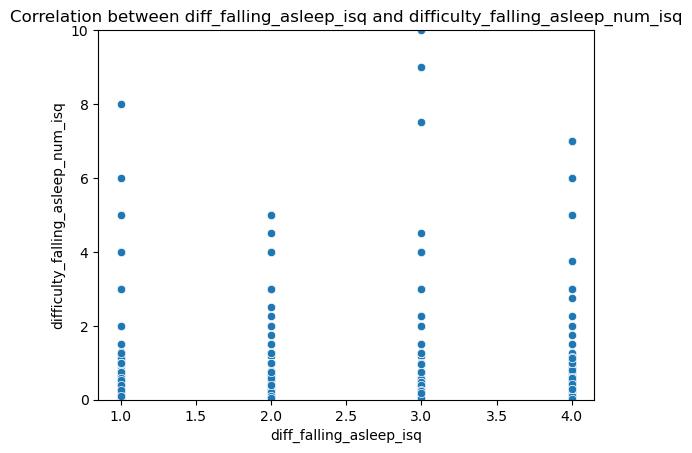

In [51]:
# scatter plot
import seaborn as sns
import matplotlib.pyplot as plt

plot = sns.scatterplot(x=col1, y=col2) # everybody. is just dumb or bad at filling stuff out i guess
plot.set_title("Correlation between diff_falling_asleep_isq and difficulty_falling_asleep_num_isq")
plt.ylim(0, 10)
plt.show()


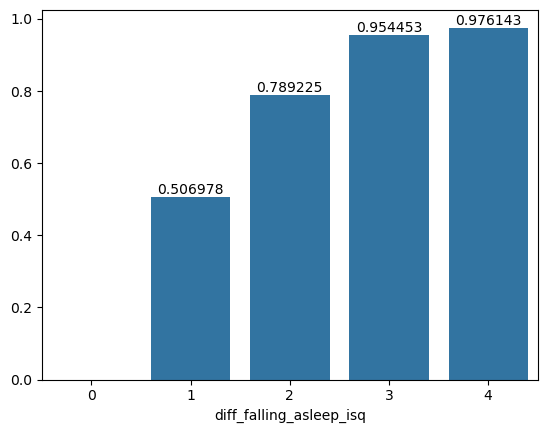

In [ ]:
# average per 1, 2, 3, 4 in diff_falling_asleep_isq

grouped_avgs = df_test.groupby("diff_falling_asleep_isq")["difficulty_falling_asleep_num_isq"].mean()

sns.barplot(x=grouped_avgs.index, y=grouped_avgs.values)
ax = plt.gca()
ax.bar_label(ax.containers[0], fontsize=10);

plt.show()


In [56]:
falling_asleep_val_dict = { #this is just for keeping track of stuff most certainly not perfect
    0.51: "rarely",
    0.80: "sometimes",
    0.95: "often",
}

In [59]:
df_test_copy = df_test.copy()

df_test_copy = df_test_copy.drop(columns=total_cols)

In [62]:
corr_matrix = df_test_copy.select_dtypes(include="number").corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr_pairs = (
    upper.stack()
    .reset_index()
    .rename(columns={'level_0': 'feature_1', 'level_1': 'feature_2', 0: 'correlation'})
    .query('correlation > 0.7')
    .sort_values('correlation', ascending=False)
)
print(high_corr_pairs)

                                              feature_1  \
5973                            cataplexy_days_per_week   
4881                num_hypnogogic_hallus_days_per_week   
6486                  difficulty_staying_asleep_num_isq   
4879                num_hypnogogic_hallus_days_per_week   
6034         map_index_4_narcolepsy_like_symptoms_score   
6379                  difficulty_falling_asleep_num_isq   
249                                       weight_pounds   
6381                  difficulty_falling_asleep_num_isq   
6786                               snorting_gasping_map   
3118              not_able_to_control_worrying_freq_gad   
4301                fati_top_three_disabling_sympts_fss   
6350                            diff_falling_asleep_isq   
4217          fati_interferes_with_responsibilities_fss   
6875                                breathing_stops_map   
4046                  fati_causes_freq_probs_for_me_fss   
4044                  fati_causes_freq_probs_for_me_fss 

for things like narcolepsy / other sleep issues it might be best to just take the total 
scores but ima look inoit that

prolly can just take the total score for GAD there is little overlap in questions.

just take ESS score too because that seems more geared to other disorders
- map index 3 and 4 are similar so perhaps look for similarities





In [ ]:
difficulty_sleeping_group = [
    "difficulty_staying_asleep_num_isq",
    "multiple_awakenings_num_isq",
    "difficulty_falling_asleep_num_isq",
    "multiple_awakenings_num_isq",
    "diff_falling_asleep_isq",
    "diff_falling_asleep_isi",
    "feel_sleep_not_sound_isq",
    "feel_sleep_unrefreshing_isq",
    "how_much_does_your_sleep_bother_you_isq"
    #hrs awake/num awakenings 
]

"total_slp_duration_sw"
"amt_slp_fully_rested"
"slp_quality_sw"
"latency_sw"

fatigue_group = [
    "fss_total_score", #NEED TO RE ADD EVENTUALLY
    "sleep_made_you_fatigued_isq",
    "how_sleepy_do_you_feel_during_the_day_isq",
    "difficulty_concentrating_fosq",
    
]
# jsut drop weight 

apnea_symtomps_group = [
    "map_index_1_apnea_score", # means apnea symtomps 
    "frequent_wakenings_map",
    "frequent_tossing_turning_map",
    "morning_headache_map"
]

nap_group = [
    "easily_awake_after_nap",
    "nap_num",
    "feel_refreshed_after_nap",
    "usual_nap_duration"
]


depression_symtomps_group = [
    "phq_total_score",
    "trouble_sleeping_or_too_much_sleep_freq_phq",
    "feel_depressed_freq_phq",
    "little_interest_or_pleasure_freq_phq",
    "feel_no_energy_freq_phq",
    "poor_appetite_overeat_freq_phq",
    "feel_bad_abt_yourself_freq_phq",
    "trouble_focusing_freq_phq",
    "slow_move_or_speak_freq_phq",
    "thought_you_would_be_better_dead_freq_phq"
]


In [ ]:
df_test_cols = df_test.columns.tolist()
df_test_cols

In [64]:
alt_df = df_test.copy()


In [65]:
alt_df = alt_df.drop(
    columns=[
        "feeling_anxious_freq_gad",
        "not_able_to_control_worrying_freq_gad",
        "worry_too_much_diff_things_freq_gad",
        "trouble_relaxing_freq_gad",
        "cant_sit_still_freq_gad",
        "easily_annoyed_freq_gad",
        "feel_as_if_awful_might_happen_freq_gad",
    ]
)

In [67]:
alt_df = alt_df.drop(
    columns=[
        "little_interest_or_pleasure_freq_phq",
        "feel_depressed_freq_phq",
        "trouble_sleeping_or_too_much_sleep_freq_phq",
        "feel_no_energy_freq_phq",
        "poor_appetite_overeat_freq_phq",
        "feel_bad_abt_yourself_freq_phq",
        "trouble_focusing_freq_phq",
        "slow_move_or_speak_freq_phq",
        "thought_you_would_be_better_dead_freq_phq"
    ]
)

In [68]:
alt_df_cols = alt_df.columns.tolist()
alt_df_cols

['age',
 'sex',
 'height_inches',
 'weight_pounds',
 'bmi',
 'num_people_in_house',
 'sw_num_days_per_week',
 'irreg_sched',
 'sw_9am_start_diff',
 'sw_5pm_end_diff',
 'nasal_congestion_stuffiness_nose',
 'nasal_blockage_obstr_nose',
 'troub_brth_nose',
 'troub_slp_nose',
 'not_enough_air_excercise_nose',
 'bed_partners',
 'exercise_amt_or_time',
 'alcohol_consumption_rarely_or_never',
 'daily_caffeine_servings',
 'hours_between_last_caffeine_and_bedtime',
 'street_drug_consume_status',
 'heartburn_belching_after_bed_freq',
 'heavy_sweat_during_sleep_freq',
 'dry_irritated_eyes_freq',
 'routinely_travel_to_other_time_zones',
 'phq_total_score',
 'gad_total_score',
 'lower_motivation_when_fati_fss',
 'exercise_brings_fati_fss',
 'i_am_easily_fati_fss',
 'fati_interferes_with_phys_function_fss',
 'fati_causes_freq_probs_for_me_fss',
 'fati_prevents_sustained_phys_func_fss',
 'fati_interferes_with_responsibilities_fss',
 'fati_top_three_disabling_sympts_fss',
 'fati_interferes_with_work_f

In [ ]:
fatigue_group = [
    "fss_total_score", #NEED TO RE ADD EVENTUALLY
    "sleep_made_you_fatigued_isq",
    "how_sleepy_do_you_feel_during_the_day_isq",
    "difficulty_concentrating_fosq",
    "difficulty_remembering_fosq"
]
# fss score is max 63 , however 4 is the middle 
""" 
FOSQ SCALE
1 : Yes, extreme
2 : Yes, moderate
3 : Yes, a little
4 : No
"""

"""
isq questions scale
1 : Never
2 : Rarely
3 : Sometimes
4 : Frequently
5 : Always
"""

alt_df


In [ ]:
alt_df["fss_total_score"].value_counts()
fss_scores = alt_df["fss_total_score"]

fss_scores_scaled = (fss_scores / 63.0) * 4.0 + 1 # SCALED TO 0 and 5

fss_total_score
1.571429    116
5.0          55
2.587302     41
3.285714     38
2.714286     38
4.238095     38
2.333333     38
4.111111     37
1.825397     36
3.666667     36
2.968254     36
3.15873      35
2.84127      35
2.904762     35
3.031746     35
4.301587     34
1.888889     34
4.619048     33
2.269841     33
2.396825     33
3.984127     33
3.857143     33
3.095238     32
1.952381     32
2.460317     32
3.222222     32
3.349206     32
3.539683     32
3.793651     31
3.47619      31
2.777778     31
3.920635     31
3.412698     30
4.746032     30
2.015873     30
3.730159     30
4.174603     29
2.650794     28
2.52381      28
3.603175     28
4.047619     28
2.206349     28
1.761905     27
4.492063     27
2.142857     27
4.555556     25
4.428571     24
2.079365     24
4.365079     23
4.809524     22
1.698413     20
4.873016     18
4.68254      18
1.634921     14
4.936508      7
Name: count, dtype: Int64

In [ ]:
fosq_flip_dict = {
    1: 4,
    2: 3,
    3: 2,
    4: 1
}

for col in fatigue_group:
    if col == "fss_total_score":
        alt_df[col] = fss_scores_scaled
    elif "fosq" in col:
        alt_df[col] = alt_df[col].map(fosq_flip_dict)

alt_df[fatigue_group].head()

# all cols needed have same min max meanings (aka 0 means not affected and higher means very affected)


,fss_total_score,sleep_made_you_fatigued_isq,how_sleepy_do_you_feel_during_the_day_isq,difficulty_concentrating_fosq
0,4.301587,4,3,4.0
1,3.285714,4,4,4.0
2,1.761905,1,2,2.0
3,2.714286,3,3,3.0
4,<NA>,4,4,NaN


In [ ]:
# normalize and average?

from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

alt_df[fatigue_group] = scaler.fit_transform(alt_df[fatigue_group])

alt_df[fatigue_group].head()

,fss_total_score,sleep_made_you_fatigued_isq,how_sleepy_do_you_feel_during_the_day_isq,difficulty_concentrating_fosq
0,0.796296,1.00,0.75,1.000000
1,0.500000,1.00,1.00,1.000000
2,0.055556,0.25,0.50,0.333333
3,0.333333,0.75,0.75,0.666667
4,NaN,1.00,1.00,NaN


In [79]:
# combine

alt_df["fatigue_score_v1"] = alt_df[fatigue_group].mean(axis=1)

alt_df[["fatigue_score_v1"]].head()

,fatigue_score_v1
0,0.886574
1,0.875000
2,0.284722
3,0.625000
4,1.000000
